# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 80°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 405
Average Fx in the averaging interval [1095:1500]: 5.4111561948870435
Average Fz in the averaging interval [1095:1500]: 0.7633032151210455
Maximum Fz in the plotting interval [1095:None]: 1.6361175537109376 at timestep 1483
Time step where Fx drops below 1: 1500


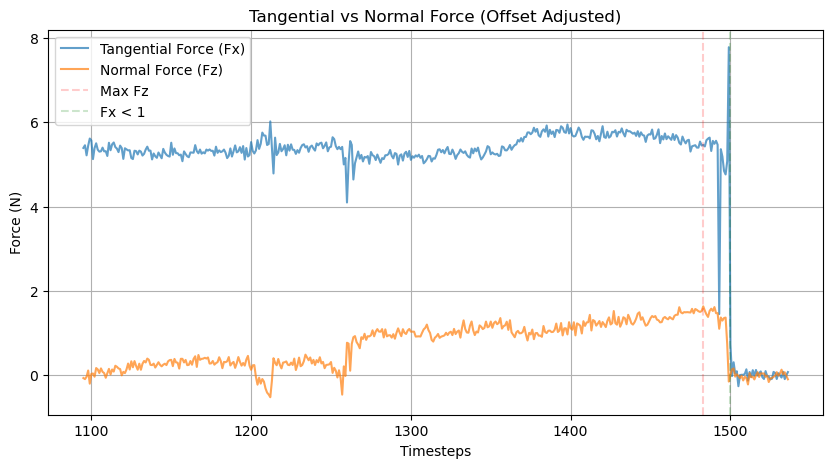

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281045.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=1095, cut_2=None, avg_end=1500, offset_position='end', offset_length=20, fx_threshold=1)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 220
Average Fx in the averaging interval [1030:1250]: 5.210208777947859
Average Fz in the averaging interval [1030:1250]: 0.31543643835819124
Maximum Fz in the plotting interval [1030:None]: 0.7918416341145833 at timestep 1194
Time step where Fx drops below 1: 1251


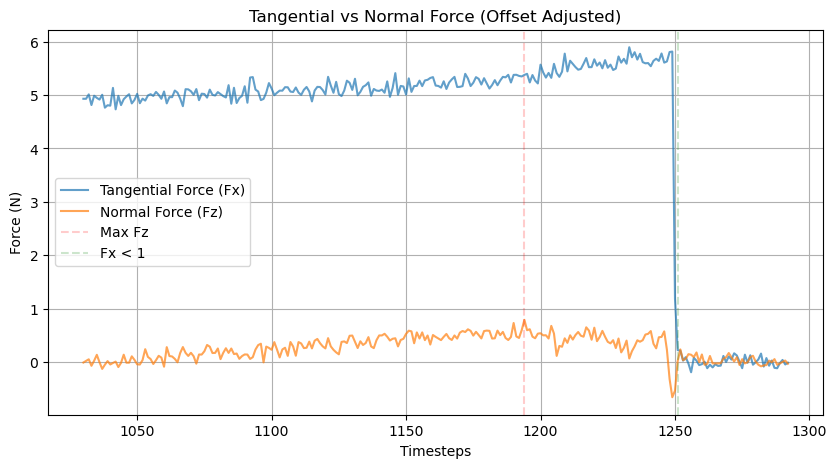

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281046.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1030, cut_2=None, avg_end=1250, offset_position='end', offset_length=15)

<font size="6">Test 3: (partialy worked / failed)</font>

Length from cut_1 to avg_end: 71
Average Fx in the averaging interval [730:801]: 5.308940370541783
Average Fz in the averaging interval [730:801]: 0.012303713229900204
Maximum Fz in the plotting interval [730:None]: 0.3131795247395833 at timestep 765
Time step where Fx drops below 1: 801


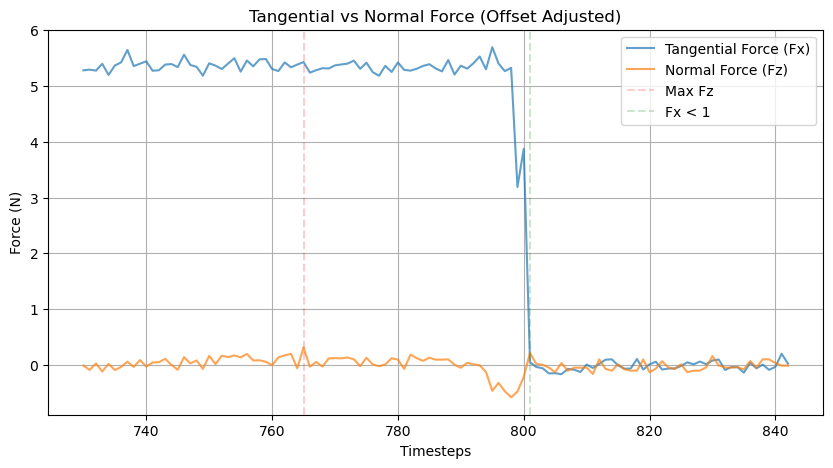

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281050.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=730, cut_2=None, avg_end=801, offset_position='end', offset_length=15)

<font size="6">Test 4: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.2033863702874665
Average Fz in the averaging interval [None:None]: -1.1805046586744177
Maximum Fz in the plotting interval [None:None]: 0.1741943359375 at timestep 807
Time step where Fx drops below 1: 0


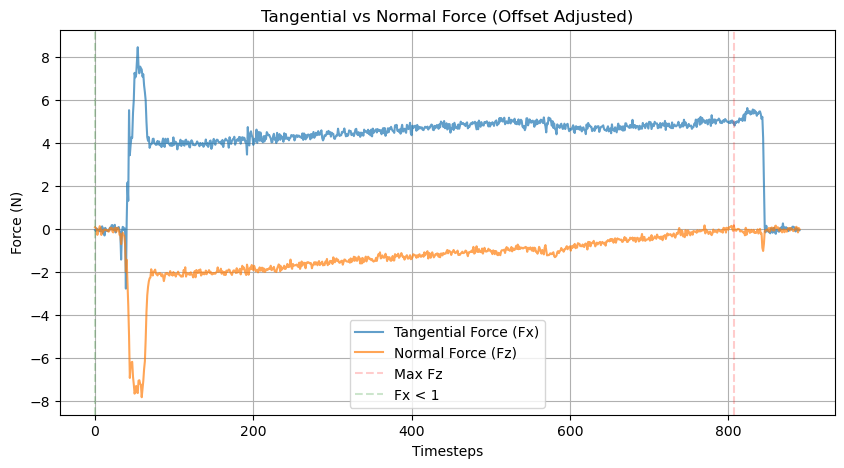

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281051.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 637
Average Fx in the averaging interval [680:1317]: 4.957684531129511
Average Fz in the averaging interval [680:1317]: 0.975620776405514
Maximum Fz in the plotting interval [680:None]: 2.1384765625 at timestep 1067
Time step where Fx drops below 0.0: 1317


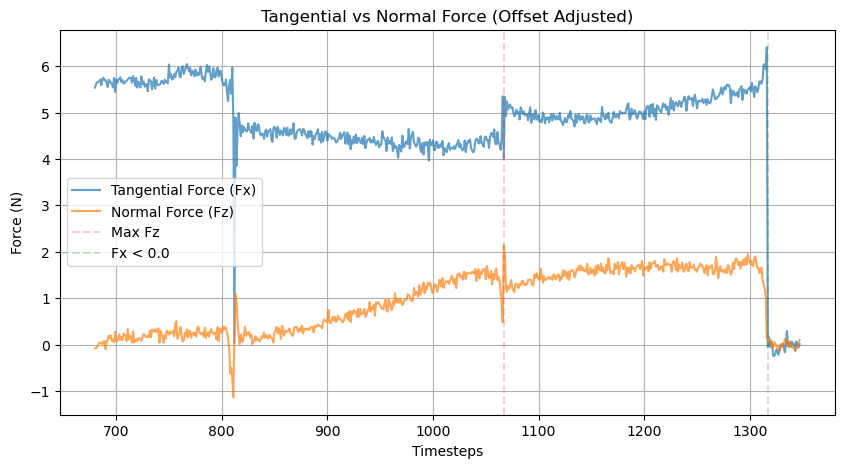

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281052.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=680, cut_2=None, avg_end=1317, offset_position='end', offset_length=15, fx_threshold=0.0)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 459
Average Fx in the averaging interval [890:1349]: 5.424222003089056
Average Fz in the averaging interval [890:1349]: 0.6909316119025736
Maximum Fz in the plotting interval [890:None]: 1.7614176432291666 at timestep 1340
Time step where Fx drops below 1: 1349


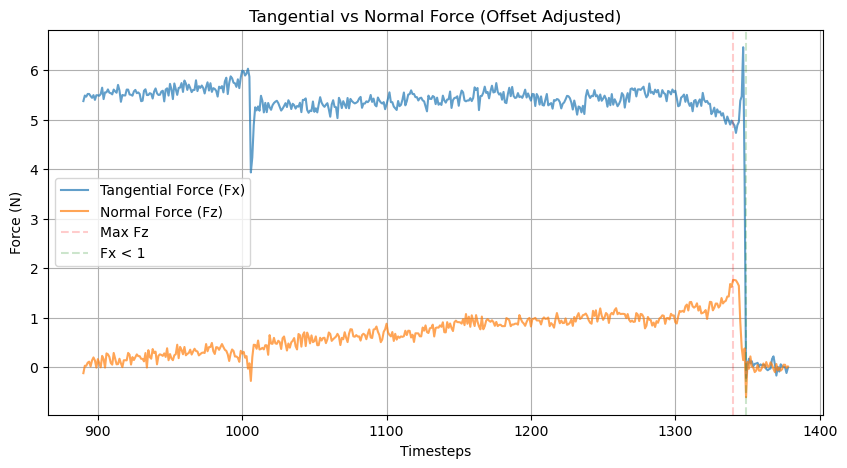

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281055.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=890, cut_2=None, avg_end=1349, offset_position='end', offset_length=15)

<font size="6">Test 7: (partialy worked / failed)</font>

Length from cut_1 to avg_end: 252
Average Fx in the averaging interval [810:1062]: 5.716638529489911
Average Fz in the averaging interval [810:1062]: 0.06643952869233627
Maximum Fz in the plotting interval [810:None]: 0.4236165364583333 at timestep 996
Time step where Fx drops below 1: 1062


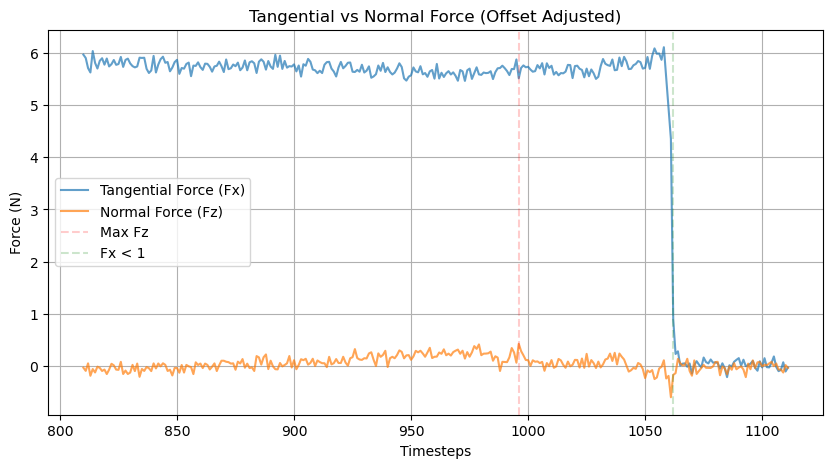

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281058.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=810, cut_2=None, avg_end=1062, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 452
Average Fx in the averaging interval [1050:1502]: 5.822975905665958
Average Fz in the averaging interval [1050:1502]: 0.46949849986748715
Maximum Fz in the plotting interval [1050:None]: 1.1665974934895833 at timestep 1312
Time step where Fx drops below 1: 1502


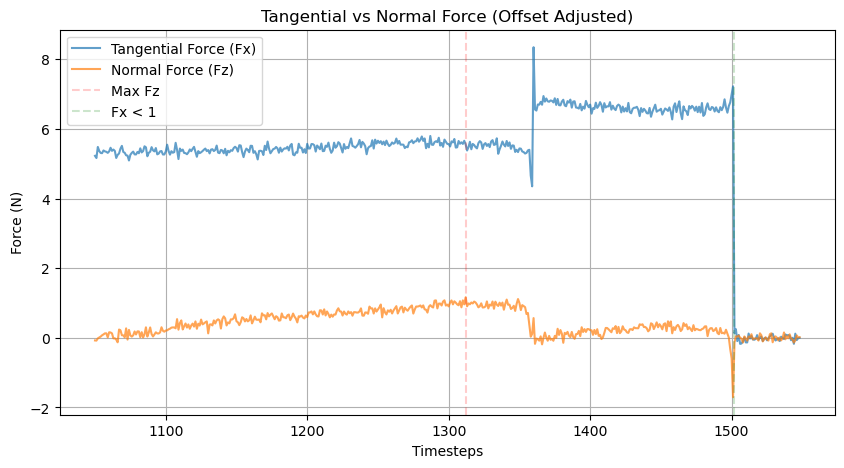

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281059.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=1050, cut_2=None, avg_end=1502, offset_position='end', offset_length=15)

<font size="6">Test 9: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.786559449807323
Average Fz in the averaging interval [None:None]: -1.59870525993029
Maximum Fz in the plotting interval [None:None]: 0.19825846354166665 at timestep 1072
Time step where Fx drops below 1: 0


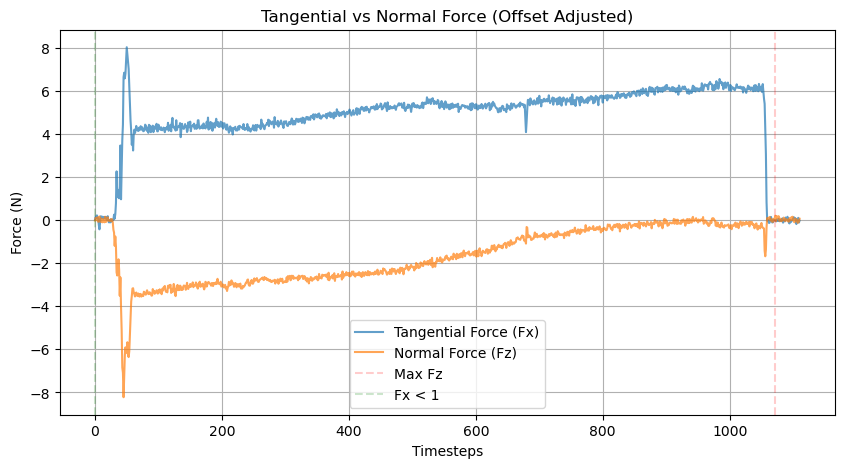

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281101.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 643
Average Fx in the averaging interval [750:1393]: 5.808794314827927
Average Fz in the averaging interval [750:1393]: 0.756384163436771
Maximum Fz in the plotting interval [750:None]: 1.68079833984375 at timestep 1332
Time step where Fx drops below 1: 1393


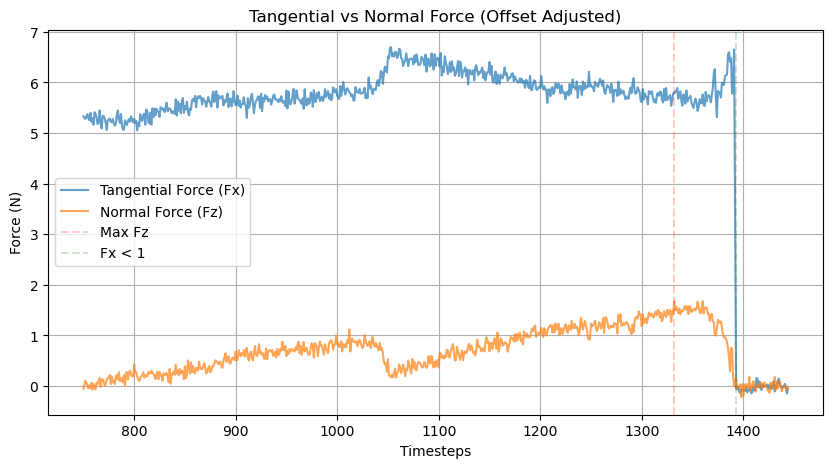

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281102.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=750, cut_2=None, avg_end=1393, offset_position='end', offset_length=15)

<font size="6">Test 11: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.717641541944153
Average Fz in the averaging interval [None:None]: -1.9066070907417387
Maximum Fz in the plotting interval [None:None]: 0.33756510416666663 at timestep 954
Time step where Fx drops below 1: 0


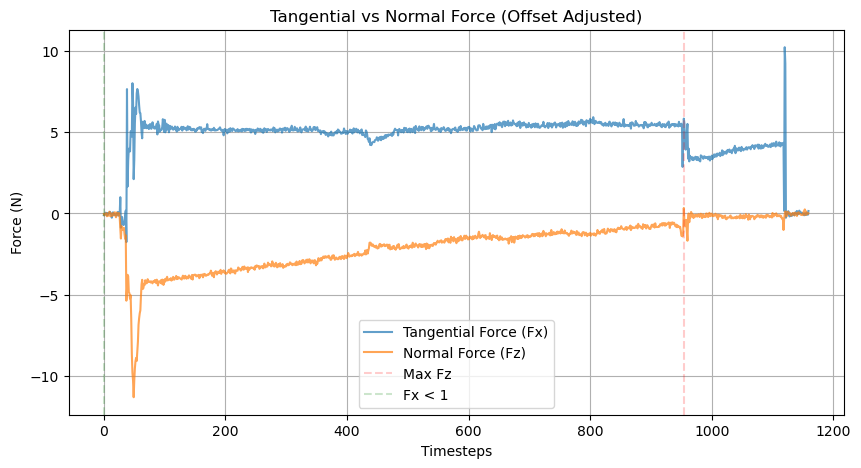

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_80_5N//log_202405281103.csv"
df = pd.read_csv(data)
test_11, end_11 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

In [14]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [18]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//80//Asphalt_80_stats.csv", index=False)

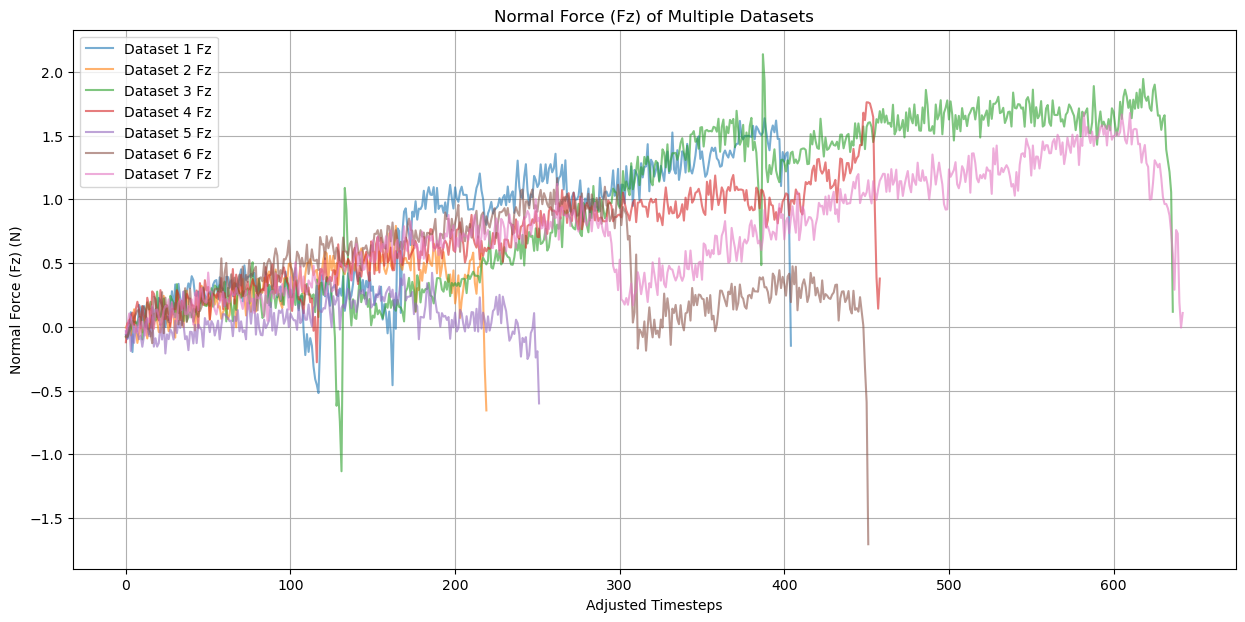

Average of maximum Fz forces: 1.3712665376209079
Standard deviation of maximum Fz forces: 0.5583711343754306
Average of average Fz forces: 0.5768020333977028
Standard deviation of average Fz forces: 0.28770279592096065
Average of average Fx forces: 5.478811465291037
Standard deviation of average Fx forces: 0.3012302123023501


In [19]:
tests = [test_1, test_2, test_5, test_6, test_7, test_8, test_10]
ends = [end_1, end_2, end_5, end_6, end_7, end_8, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [20]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//80//Asphalt_80"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)